In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/content/preparations.py'>

In [2]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Imports for image transformations
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomBrightness

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Importing Keras utility for image dataset loading
from keras.utils import image_dataset_from_directory

# Reporting
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Trials with some constellations of CNN layers

##### Dataset loading and preprocessing

In [5]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()

Dataset already exists.


In [6]:
# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images()

Created empty directory: /tmp_97133179
Made directory: /tmp_97133179/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_97133179/Lung_Opacity/masks
Made directory: /tmp_97133179/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_97133179/COVID/masks
Made directory: /tmp_97133179/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_97133179/Viral Pneumonia/masks
Made directory: /tmp_97133179/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_97133179/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 224, 224, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 224, 224, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_97133179/Lung_Opacity/

In [7]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [8]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [9]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [10]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))

# This model name for saving and loading
model_name = os.path.join('..', 'models', '3b_vgg16_augmented_dense512.keras')

In [11]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
# Apply random translation of up to +-20% in either direction
x = RandomTranslation(0.2, 0.2)(inputs)
# Apply random zoom +-20%
x = RandomZoom(0.2)(x)
# Apply random horizontal and vertical flipping to images
x = RandomFlip("horizontal_and_vertical")(x)
# Perform random rotation of up to 20% (in radians) in either direction
x = RandomRotation(0.2)(x)
# Randomly adjust image contrast by ±20%
x = RandomContrast(factor=0.2)(x)
# Randomly adjust image brightness by ±10%
x = RandomBrightness(factor=0.1)(x)

# Build the model
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [13]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
from helper import model_summary_to_df
df_summary = model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation                   │ (None, 224, 224, 3)         │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_brightness (RandomBrightness) │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,random_translation,"(None, 224, 224, 3)",0
2,(RandomTranslation),,
3,random_zoom (RandomZoom),"(None, 224, 224, 3)",0
4,random_flip (RandomFlip),"(None, 224, 224, 3)",0
5,random_rotation (RandomRotation),"(None, 224, 224, 3)",0
6,random_contrast (RandomContrast),"(None, 224, 224, 3)",0
7,random_brightness (RandomBrightness),"(None, 224, 224, 3)",0
8,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
9,global_average_pooling2d,"(None, 512)",0


In [14]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.6010 - loss: 1.0079 - val_accuracy: 0.4978 - val_loss: 1.8973 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7212 - loss: 0.6045 - val_accuracy: 0.5729 - val_loss: 1.0968 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7445 - loss: 0.5589 - val_accuracy: 0.6645 - val_loss: 1.0004 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7572 - loss: 0.5367 - val_accuracy: 0.5845 - val_loss: 1.3129 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7703 - loss: 0.5067 - val_accuracy: 0.5507 - val_loss: 1.2684 - learning_rate: 0.0010
Epoch 6/25
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7634 - loss: 0.5138
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
530/530 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7634 - lo

In [15]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

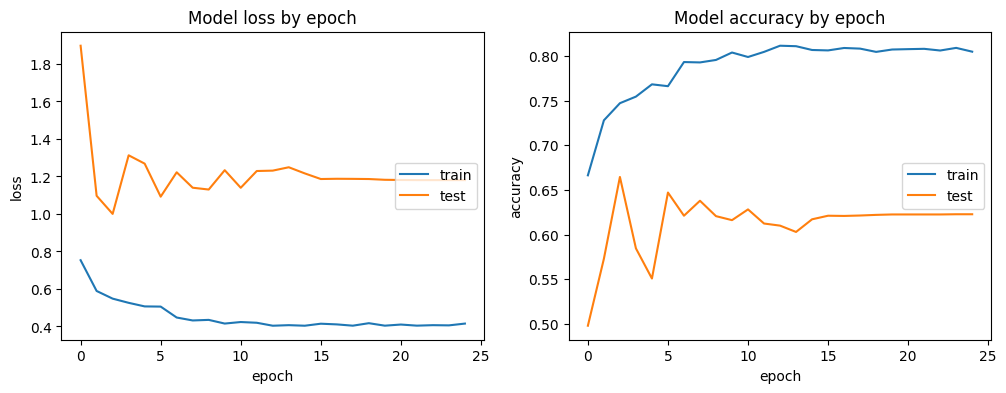

In [16]:
hlp.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [17]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [18]:
y_true, y_pred = hlp.get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.510260,0.523142,0.898295,0.516620,0.685519,0.452306,713.000000
Lung_Opacity,0.581851,0.842060,0.770209,0.688180,0.805333,0.653222,1165.000000
Normal,0.801105,0.493197,0.884138,0.610526,0.660344,0.419007,2058.000000
Viral Pneumonia,0.486339,0.898990,0.928354,0.631206,0.913554,0.832130,297.000000
avg_pre,0.669688,0.669688,0.669688,0.669688,0.669688,0.669688,0.669688
avg_rec,0.622726,0.622726,0.622726,0.622726,0.622726,0.622726,0.622726
avg_spe,0.858269,0.858269,0.858269,0.858269,0.858269,0.858269,0.858269
avg_f1,0.617532,0.617532,0.617532,0.617532,0.617532,0.617532,0.617532
avg_geo,0.722254,0.722254,0.722254,0.722254,0.722254,0.722254,0.722254
avg_iba,0.518062,0.518062,0.518062,0.518062,0.518062,0.518062,0.518062


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,373,213,117,10
Lung_Opacity,62,981,119,3
Normal,291,483,1015,269
Viral Pneumonia,5,9,16,267


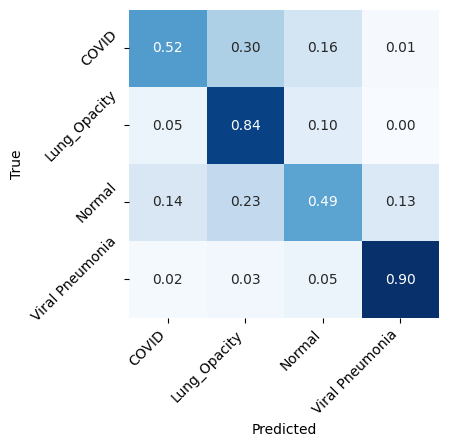

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              373           213     117               10
 Lung_Opacity        62           981     119                3
 Normal             291           483    1015              269
 Viral Pneumonia      5             9      16              267,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.510260     0.523142     0.898295     0.516620   
 Lung_Opacity        0.581851     0.842060     0.770209     0.688180   
 Normal              0.801105     0.493197     0.884138     0.610526   
 Viral Pneumonia     0.486339     0.898990     0.928354     0.631206   
 avg_pre             0.669688     0.669688     0.669688     0.669688   
 avg_rec             0.622726     0.622726     0.622726     0.622726   
 avg_spe             0.858269     0.858269     0.858269     0.858269   
 avg_f1              0.617532     0.617532     0.617532     0.617532   

In [19]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Data Augmentation with VGG16 made it just worse